# One-to-Many Face Search

## Project Objective

The goal of this stage is to search a single query face against a
database containing multiple people and identify the most likely
matching person.

### Pipeline

Query Image

↓

Face Detection

↓

ArcFace Feature Extraction

↓

512-D Face Embedding

↓

Compare with Database Embeddings

↓

Calculate Face Distance

↓

Rank Candidates

↓

Potential Match

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from deepface import DeepFace

print("All required libraries imported successfully!")

All required libraries imported successfully!


In [2]:
DATABASE_DIR = "face_database_test"

print("Database directory:", DATABASE_DIR)
print("Database exists:", os.path.exists(DATABASE_DIR))


Database directory: face_database_test
Database exists: True


In [3]:
people = os.listdir(DATABASE_DIR)

print("Number of people:", len(people))
print("People:", people)

for person in sorted(people):
    person_path = os.path.join(DATABASE_DIR, person)

    if os.path.isdir(person_path):
        images = os.listdir(person_path)
        print(f"{person}: {len(images)} image(s)")

Number of people: 8
People: ['person5', 'person2', 'person3', 'person4', 'person1', 'person6', 'person8', 'person7']
person1: 7 image(s)
person2: 2 image(s)
person3: 3 image(s)
person4: 2 image(s)
person5: 2 image(s)
person6: 2 image(s)
person7: 2 image(s)
person8: 2 image(s)


In [4]:
query_image_path = "photo1.jpg"

query_image = cv2.imread(query_image_path)

print("Query image:", query_image_path)
print("Image loaded:", query_image is not None)
print("Image shape:", query_image.shape if query_image is not None else None)

Query image: photo1.jpg
Image loaded: True
Image shape: (413, 413, 3)


In [5]:
query_embedding_result = DeepFace.represent(
    img_path=query_image_path,
    model_name="ArcFace",
    detector_backend="opencv",
    enforce_detection=True
)

query_embedding = np.array(
    query_embedding_result[0]["embedding"]
)

print("Embedding shape:", query_embedding.shape)
print("Embedding type:", query_embedding.dtype)

Embedding shape: (512,)
Embedding type: float64


In [6]:
def cosine_distance(embedding_a, embedding_b):
    similarity = np.dot(embedding_a, embedding_b) / (
        np.linalg.norm(embedding_a) * np.linalg.norm(embedding_b)
    )
    
    distance = 1 - similarity
    return distance


print("Cosine distance function created!")

Cosine distance function created!


In [7]:
distance = cosine_distance(query_embedding, query_embedding)

print("Distance between query and itself:", round(distance, 4))

Distance between query and itself: 0.0


In [8]:
results = []

for person in sorted(os.listdir(DATABASE_DIR)):
    person_path = os.path.join(DATABASE_DIR, person)

    if not os.path.isdir(person_path):
        continue

    for image_name in sorted(os.listdir(person_path)):
        image_path = os.path.join(person_path, image_name)

        if not image_name.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        embedding_result = DeepFace.represent(
            img_path=image_path,
            model_name="ArcFace",
            detector_backend="opencv",
            enforce_detection=True
        )

        database_embedding = np.array(
            embedding_result[0]["embedding"]
        )

        distance = cosine_distance(
            query_embedding,
            database_embedding
        )

        results.append({
            "person": person,
            "image": image_name,
            "distance": distance
        })

print("Total database images compared:", len(results))

Total database images compared: 22


In [9]:
sorted_results = sorted(
    results,
    key=lambda x: x["distance"]
)

print("Top matches:")
print()

for result in sorted_results:
    print(
        f'{result["person"]} | '
        f'{result["image"]} | '
        f'distance: {result["distance"]:.4f}'
    )

Top matches:

person8 | img24.jpg | distance: 0.7056
person2 | img12.jpg | distance: 0.7867
person8 | img25.jpg | distance: 0.8308
person1 | img6.jpg | distance: 0.8727
person1 | img4.jpg | distance: 0.8732
person1 | img11.jpg | distance: 0.8738
person1 | img2.jpg | distance: 0.8834
person1 | img7.jpg | distance: 0.8923
person2 | img3.jpg | distance: 0.8937
person1 | img10.jpg | distance: 0.9064
person3 | img14.jpg | distance: 0.9136
person1 | img5.jpg | distance: 0.9145
person6 | img21.jpg | distance: 0.9710
person3 | img13.jpg | distance: 0.9790
person4 | img17.jpg | distance: 1.0010
person3 | img15.jpg | distance: 1.0455
person6 | img20.jpg | distance: 1.0624
person7 | img23.jpg | distance: 1.0813
person4 | img16.jpg | distance: 1.0864
person5 | img18.jpg | distance: 1.1234
person7 | img22.jpg | distance: 1.1797
person5 | img19.jpg | distance: 1.1822


In [10]:
person_results = {}

for result in results:
    person = result["person"]
    distance = result["distance"]

    if person not in person_results:
        person_results[person] = []

    person_results[person].append(distance)

print("Number of people:", len(person_results))

for person, distances in person_results.items():
    print(
        f"{person}: "
        f"{len(distances)} photos, "
        f"best distance = {min(distances):.4f}, "
        f"average distance = {np.mean(distances):.4f}"
    )

Number of people: 8
person1: 7 photos, best distance = 0.8727, average distance = 0.8880
person2: 2 photos, best distance = 0.7867, average distance = 0.8402
person3: 3 photos, best distance = 0.9136, average distance = 0.9793
person4: 2 photos, best distance = 1.0010, average distance = 1.0437
person5: 2 photos, best distance = 1.1234, average distance = 1.1528
person6: 2 photos, best distance = 0.9710, average distance = 1.0167
person7: 2 photos, best distance = 1.0813, average distance = 1.1305
person8: 2 photos, best distance = 0.7056, average distance = 0.7682


In [11]:
ranked_people = []

for person, distances in person_results.items():
    ranked_people.append({
        "person": person,
        "best_distance": min(distances),
        "average_distance": np.mean(distances),
        "photo_count": len(distances)
    })

ranked_people = sorted(
    ranked_people,
    key=lambda x: x["best_distance"]
)

print("Person-level ranking:")
print()

for rank, person in enumerate(ranked_people, start=1):
    print(
        f"{rank}. {person['person']} | "
        f"best: {person['best_distance']:.4f} | "
        f"average: {person['average_distance']:.4f} | "
        f"photos: {person['photo_count']}"
    )

Person-level ranking:

1. person8 | best: 0.7056 | average: 0.7682 | photos: 2
2. person2 | best: 0.7867 | average: 0.8402 | photos: 2
3. person1 | best: 0.8727 | average: 0.8880 | photos: 7
4. person3 | best: 0.9136 | average: 0.9793 | photos: 3
5. person6 | best: 0.9710 | average: 1.0167 | photos: 2
6. person4 | best: 1.0010 | average: 1.0437 | photos: 2
7. person7 | best: 1.0813 | average: 1.1305 | photos: 2
8. person5 | best: 1.1234 | average: 1.1528 | photos: 2


In [12]:
top_candidate = ranked_people[0]

print("==============================")
print("     TOP POTENTIAL MATCH")
print("==============================")
print(f"Person:            {top_candidate['person']}")
print(f"Best distance:     {top_candidate['best_distance']:.4f}")
print(f"Average distance:  {top_candidate['average_distance']:.4f}")
print(f"Reference photos:  {top_candidate['photo_count']}")

     TOP POTENTIAL MATCH
Person:            person8
Best distance:     0.7056
Average distance:  0.7682
Reference photos:  2


In [13]:
SEARCH_THRESHOLD = 0.68

if top_candidate["best_distance"] <= SEARCH_THRESHOLD:
    decision = "POTENTIAL MATCH"
else:
    decision = "NO RELIABLE MATCH"

print("==============================")
print("      SEARCH RESULT")
print("==============================")
print(f"Decision:          {decision}")
print(f"Person:            {top_candidate['person']}")
print(f"Best distance:     {top_candidate['best_distance']:.4f}")
print(f"Threshold:         {SEARCH_THRESHOLD:.2f}")

      SEARCH RESULT
Decision:          NO RELIABLE MATCH
Person:            person8
Best distance:     0.7056
Threshold:         0.68


In [14]:
print("==============================")
print("       TOP 3 CANDIDATES")
print("==============================")

for rank, candidate in enumerate(ranked_people[:3], start=1):
    print(
        f"{rank}. {candidate['person']} | "
        f"best distance: {candidate['best_distance']:.4f} | "
        f"average distance: {candidate['average_distance']:.4f}"
    )

       TOP 3 CANDIDATES
1. person8 | best distance: 0.7056 | average distance: 0.7682
2. person2 | best distance: 0.7867 | average distance: 0.8402
3. person1 | best distance: 0.8727 | average distance: 0.8880


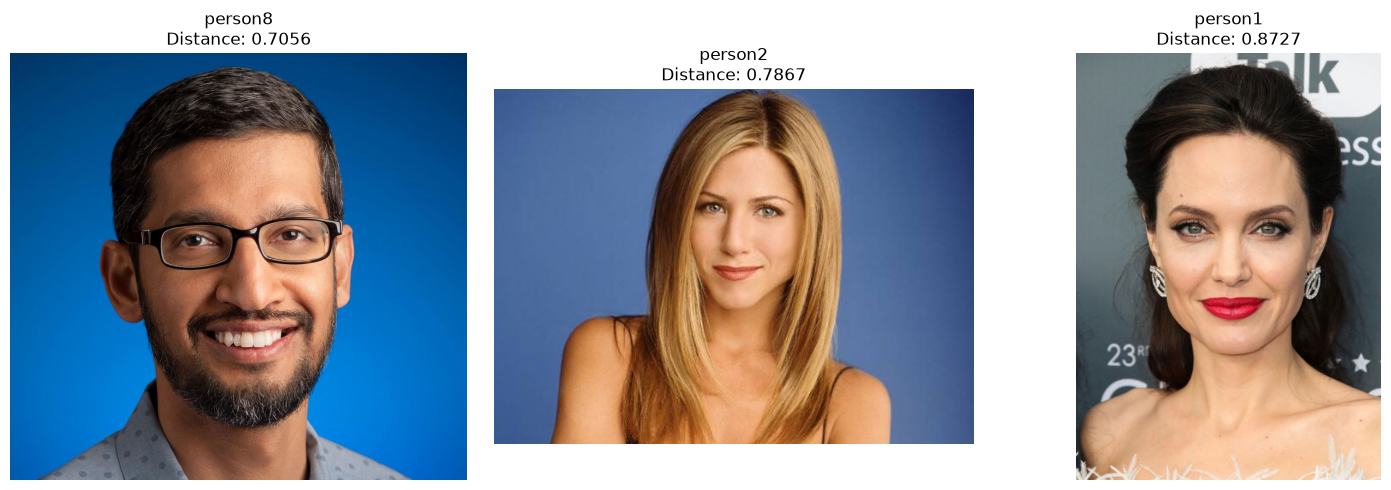

In [15]:
top_people = ranked_people[:3]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, candidate in zip(axes, top_people):
    person = candidate["person"]

    # Find the best matching photo for this person
    person_results_for_candidate = [
        r for r in results
        if r["person"] == person
    ]

    best_photo = min(
        person_results_for_candidate,
        key=lambda x: x["distance"]
    )

    image_path = os.path.join(
        DATABASE_DIR,
        person,
        best_photo["image"]
    )

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ax.imshow(image)
    ax.set_title(
        f"{person}\nDistance: {best_photo['distance']:.4f}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

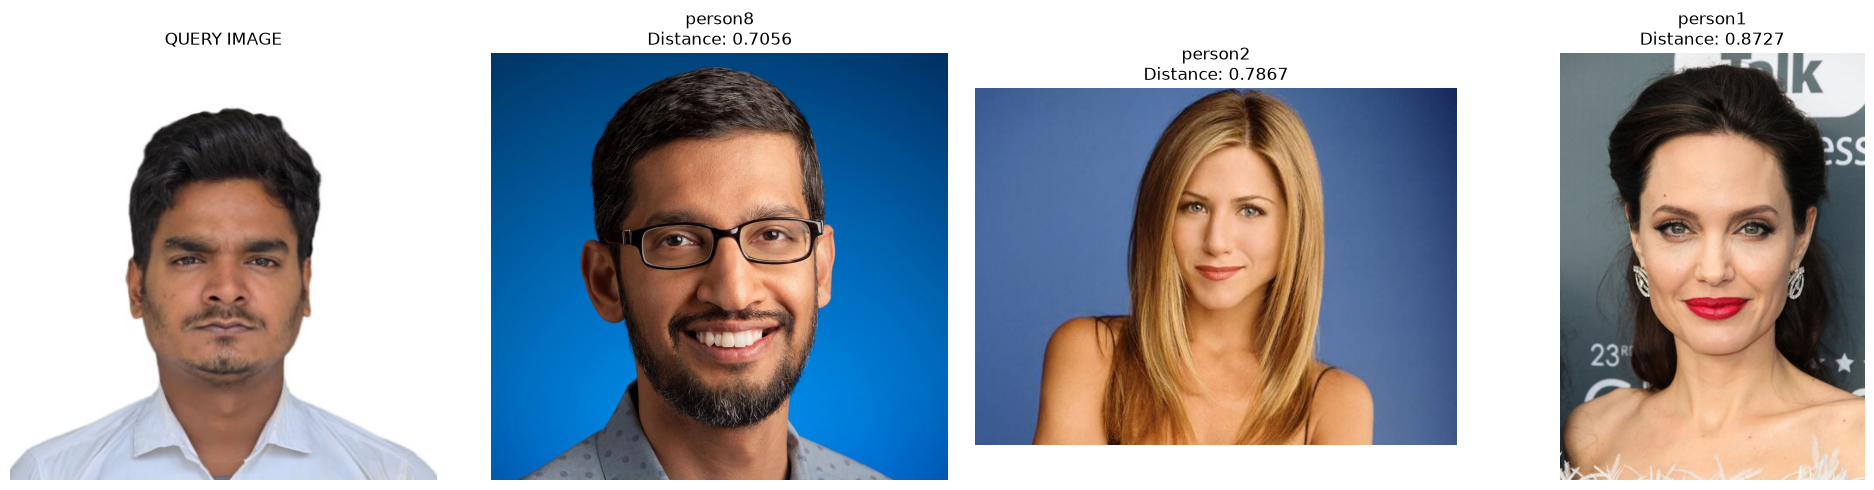

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Query image
query_rgb = cv2.cvtColor(query_image, cv2.COLOR_BGR2RGB)

axes[0].imshow(query_rgb)
axes[0].set_title("QUERY IMAGE")
axes[0].axis("off")

# Top 3 candidates
for ax, candidate in zip(axes[1:], top_people):
    person = candidate["person"]

    candidate_results = [
        r for r in results
        if r["person"] == person
    ]

    best_photo = min(
        candidate_results,
        key=lambda x: x["distance"]
    )

    image_path = os.path.join(
        DATABASE_DIR,
        person,
        best_photo["image"]
    )

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ax.imshow(image)
    ax.set_title(
        f"{person}\nDistance: {best_photo['distance']:.4f}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [17]:
test_query_path = os.path.join(
    DATABASE_DIR,
    "person1",
    "img2.jpg"
)

print("Test query:", test_query_path)
print("Image exists:", os.path.exists(test_query_path))

Test query: face_database_test/person1/img2.jpg
Image exists: True


In [18]:
test_query_embedding_result = DeepFace.represent(
    img_path=test_query_path,
    model_name="ArcFace",
    detector_backend="opencv",
    enforce_detection=True
)

test_query_embedding = np.array(
    test_query_embedding_result[0]["embedding"]
)

print("Test query embedding shape:", test_query_embedding.shape)

Test query embedding shape: (512,)


In [19]:
test_results = []

for person in sorted(os.listdir(DATABASE_DIR)):
    person_path = os.path.join(DATABASE_DIR, person)

    if not os.path.isdir(person_path):
        continue

    for image_name in sorted(os.listdir(person_path)):
        if not image_name.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        image_path = os.path.join(person_path, image_name)

        embedding_result = DeepFace.represent(
            img_path=image_path,
            model_name="ArcFace",
            detector_backend="opencv",
            enforce_detection=True
        )

        database_embedding = np.array(
            embedding_result[0]["embedding"]
        )

        distance = cosine_distance(
            test_query_embedding,
            database_embedding
        )

        test_results.append({
            "person": person,
            "image": image_name,
            "distance": distance
        })

test_results = sorted(
    test_results,
    key=lambda x: x["distance"]
)

print("Top 5 matches:")
print()

for result in test_results[:5]:
    print(
        f"{result['person']} | "
        f"{result['image']} | "
        f"distance: {result['distance']:.4f}"
    )

Top 5 matches:

person1 | img2.jpg | distance: 0.0000
person1 | img6.jpg | distance: 0.2253
person1 | img7.jpg | distance: 0.2401
person1 | img4.jpg | distance: 0.2725
person1 | img10.jpg | distance: 0.2749


In [20]:
held_out_query_path = "/tmp/img1_query.jpg"

print("Held-out query:", held_out_query_path)
print("Image exists:", os.path.exists(held_out_query_path))

Held-out query: /tmp/img1_query.jpg
Image exists: True


In [21]:
held_out_embedding_result = DeepFace.represent(
    img_path=held_out_query_path,
    model_name="ArcFace",
    detector_backend="opencv",
    enforce_detection=True
)

held_out_embedding = np.array(
    held_out_embedding_result[0]["embedding"]
)

print("Held-out embedding shape:", held_out_embedding.shape)

Held-out embedding shape: (512,)


In [22]:
held_out_results = []

for person in sorted(os.listdir(DATABASE_DIR)):
    person_path = os.path.join(DATABASE_DIR, person)

    if not os.path.isdir(person_path):
        continue

    for image_name in sorted(os.listdir(person_path)):
        if not image_name.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        image_path = os.path.join(person_path, image_name)

        embedding_result = DeepFace.represent(
            img_path=image_path,
            model_name="ArcFace",
            detector_backend="opencv",
            enforce_detection=True
        )

        database_embedding = np.array(
            embedding_result[0]["embedding"]
        )

        distance = cosine_distance(
            held_out_embedding,
            database_embedding
        )

        held_out_results.append({
            "person": person,
            "image": image_name,
            "distance": distance
        })

held_out_results = sorted(
    held_out_results,
    key=lambda x: x["distance"]
)

print("Top 5 matches for held-out query:")
print()

for result in held_out_results[:5]:
    print(
        f"{result['person']} | "
        f"{result['image']} | "
        f"distance: {result['distance']:.4f}"
    )

Top 5 matches for held-out query:

person1 | img4.jpg | distance: 0.4969
person1 | img2.jpg | distance: 0.5078
person1 | img11.jpg | distance: 0.5182
person1 | img7.jpg | distance: 0.5230
person1 | img5.jpg | distance: 0.5399


In [24]:
held_out_person_results = {}

for result in held_out_results:
    person = result["person"]
    distance = result["distance"]

    if person not in held_out_person_results:
        held_out_person_results[person] = []

    held_out_person_results[person].append(distance)

held_out_ranked_people = []

for person, distances in held_out_person_results.items():
    held_out_ranked_people.append({
        "person": person,
        "best_distance": min(distances),
        "average_distance": np.mean(distances),
        "photo_count": len(distances)
    })

held_out_ranked_people = sorted(
    held_out_ranked_people,
    key=lambda x: x["best_distance"]
)

print("Held-out person-level ranking:")
print()

for rank, candidate in enumerate(held_out_ranked_people, start=1):
    print(
        f"{rank}. {candidate['person']} | "
        f"best: {candidate['best_distance']:.4f} | "
        f"average: {candidate['average_distance']:.4f} | "
        f"photos: {candidate['photo_count']}"
    )

Held-out person-level ranking:

1. person1 | best: 0.4969 | average: 0.5463 | photos: 7
2. person8 | best: 0.8300 | average: 0.8344 | photos: 2
3. person7 | best: 0.8723 | average: 0.9018 | photos: 2
4. person2 | best: 0.9216 | average: 0.9686 | photos: 2
5. person4 | best: 0.9506 | average: 0.9700 | photos: 2
6. person5 | best: 0.9633 | average: 0.9884 | photos: 2
7. person6 | best: 0.9712 | average: 1.0106 | photos: 2
8. person3 | best: 1.0460 | average: 1.1096 | photos: 3


In [25]:
SEARCH_THRESHOLD = 0.68

top_candidate = held_out_ranked_people[0]

if top_candidate["best_distance"] <= SEARCH_THRESHOLD:
    decision = "POTENTIAL MATCH"
else:
    decision = "NO RELIABLE MATCH"

print("==============================")
print("   HELD-OUT SEARCH RESULT")
print("==============================")
print(f"Expected person:   person1")
print(f"Predicted person:  {top_candidate['person']}")
print(f"Best distance:     {top_candidate['best_distance']:.4f}")
print(f"Threshold:         {SEARCH_THRESHOLD:.2f}")
print(f"Decision:          {decision}")

   HELD-OUT SEARCH RESULT
Expected person:   person1
Predicted person:  person1
Best distance:     0.4969
Threshold:         0.68
Decision:          POTENTIAL MATCH


# One-to-Many Face Search Architecture

The one-to-many system searches a single query face against
multiple reference images belonging to different people.

```text
                         Query Image
                              │
                              ▼
                       Face Detection
                              │
                              ▼
                         ArcFace Model
                              │
                              ▼
                     512-D Query Embedding
                              │
                              ▼
                 ┌─────────────────────────┐
                 │     Face Database       │
                 │                         │
                 │ Person 1 → Images       │
                 │ Person 2 → Images       │
                 │ Person 3 → Images       │
                 │        ...              │
                 │ Person N → Images       │
                 └────────────┬────────────┘
                              │
                              ▼
                    Generate Embeddings
                    for Reference Images
                              │
                              ▼
                     Cosine Distance
                              │
                              ▼
                   Group Results by Person
                              │
                              ▼
                     Rank Candidates
                              │
                              ▼
                  ┌──────────────────────┐
                  │   Top Candidates     │
                  │                      │
                  │ 1. Person A          │
                  │ 2. Person B          │
                  │ 3. Person C          │
                  └──────────┬───────────┘
                             │
                             ▼
                       Apply Threshold
                             │
                    ┌────────┴────────┐
                    ▼                 ▼
             Potential Match    No Reliable Match
                    │
                    ▼
             Human Verification

# Conclusion

The one-to-many face search system was successfully implemented using
ArcFace face embeddings and cosine distance.

The system can:

- Accept a query face image.
- Generate a 512-dimensional ArcFace embedding.
- Compare the query against multiple reference images.
- Group reference images according to each person.
- Rank people based on their face distance.
- Display the top potential candidates.
- Apply a search threshold to determine whether a candidate should be
  considered a potential match.

## Held-Out Evaluation

A held-out image belonging to `person1` was removed from the database
and used as the query image.

The system correctly ranked `person1` as the top candidate.

- **Expected person:** person1
- **Predicted person:** person1
- **Best distance:** 0.4969
- **Average distance:** 0.5463
- **Search threshold:** 0.68
- **Decision:** POTENTIAL MATCH

The result demonstrates that the system can identify a person from
different reference images rather than relying on an exact image match.

## Limitation

The current implementation generates the ArcFace embedding for every
database image during each search. This becomes inefficient as the
number of people and images increases.

The search threshold of 0.68 is also currently reused from the face
verification experiment and requires further evaluation and calibration
for one-to-many identification.

## Next Stage

The next stage will focus on **precomputing and storing database face
embeddings**. This will allow the system to generate an embedding only
for the new query image and compare it against already stored
embeddings, making the search more efficient and scalable.